### General Results of the optimisation

In [1]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Get latest run
RESULTS_ROOT = Path("02-MODEL-RESULTS")
latest_run = sorted([d for d in RESULTS_ROOT.iterdir() if d.is_dir()])[-1]

# Load summary and settings
with open(latest_run / "results_summary.json", "r") as f:
    summary = json.load(f)
with open(latest_run / "settings_snapshot.json", "r") as f:
    settings = json.load(f)
active_parameters = settings.get("parameters", {})

# Load time series
df = pd.read_csv(latest_run / "timeseries_results.csv", parse_dates=['timestamp'])
df_soc = df.copy()
df_compare = pd.read_csv(latest_run / "baseline_vs_optimized.csv")
df_peak_metrics = pd.read_csv(latest_run / "peak_metrics.csv")
df_top_peaks = pd.read_csv(latest_run / "top_peak_intervals.csv", parse_dates=['timestamp'])
monthly_summary_path = latest_run / "monthly_summary.csv"
if monthly_summary_path.exists():
    df_monthly = pd.read_csv(monthly_summary_path)
else:
    df_monthly = df.copy()
    df_monthly["month"] = df_monthly["timestamp"].dt.to_period("M").astype(str)
    price_per_kwh = 0.0
    if len(df_monthly) > 0 and df_monthly["grid_flow"].sum() > 0:
        price_per_kwh = summary.get("import_cost", 0.0) / (df_monthly["grid_flow"].sum() * 0.25)
    df_monthly["baseline_import_cost"] = df_monthly["baseline_grid_import"] * price_per_kwh * 0.25
    df_monthly["optimized_import_cost"] = df_monthly["grid_flow"] * price_per_kwh * 0.25
    df_monthly = df_monthly.groupby("month", as_index=False).agg(
        monthly_import_cost_before=("baseline_import_cost", "sum"),
        monthly_import_cost_after=("optimized_import_cost", "sum"),
        monthly_peak_before=("baseline_grid_import", "max"),
        monthly_peak_after=("grid_flow", "max"),
    )
    df_monthly["monthly_savings"] = df_monthly["monthly_import_cost_before"] - df_monthly["monthly_import_cost_after"]
    df_monthly["monthly_peak_reduction"] = df_monthly["monthly_peak_before"] - df_monthly["monthly_peak_after"]
battery_utilization_path = latest_run / "battery_utilization_summary.csv"
if battery_utilization_path.exists():
    df_battery_util = pd.read_csv(battery_utilization_path)
elif {"battery_soc", "battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    installed_capacity = summary.get("battery_capacity_kwh", 0.0)
    timestep_hours = 0.25
    avg_soc = df["battery_soc"].mean()
    min_soc = df["battery_soc"].min()
    max_soc = df["battery_soc"].max()
    discharged_energy = df["battery_discharge_power"].sum() * timestep_hours
    charged_energy = df["battery_charge_power"].sum() * timestep_hours
    equivalent_cycles = discharged_energy / installed_capacity if installed_capacity else float("nan")
    df_battery_util = pd.DataFrame([
        {"Metric": "Charged energy", "Value": charged_energy, "Unit": "kWh/year"},
        {"Metric": "Discharged energy", "Value": discharged_energy, "Unit": "kWh/year"},
        {"Metric": "Equivalent full cycles", "Value": equivalent_cycles, "Unit": "cycles/year"},
        {"Metric": "Average state of charge", "Value": avg_soc, "Unit": "kWh"},
        {"Metric": "Minimum state of charge", "Value": min_soc, "Unit": "kWh"},
        {"Metric": "Maximum state of charge", "Value": max_soc, "Unit": "kWh"},
        {"Metric": "Hours near empty (<=10%)", "Value": (df["battery_soc"] <= 0.10 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Hours near full (>=90%)", "Value": (df["battery_soc"] >= 0.90 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Maximum charge power used", "Value": df["battery_charge_power"].max(), "Unit": "kW"},
        {"Metric": "Maximum discharge power used", "Value": df["battery_discharge_power"].max(), "Unit": "kW"},
    ])
else:
    df_battery_util = pd.DataFrame(columns=["Metric", "Value", "Unit"])
battery_sensitivity_path = latest_run / "battery_size_sensitivity.csv"
if battery_sensitivity_path.exists():
    df_battery_sensitivity = pd.read_csv(battery_sensitivity_path)
else:
    df_battery_sensitivity = pd.DataFrame(columns=["battery_size_kwh", "objective_total_cost", "import_cost", "peak_demand_cost", "annualized_battery_cost", "annual_savings", "npv", "irr", "payback_years", "discounted_payback_years", "status"])
df_fin = pd.read_csv(latest_run / "financial_cashflows.csv")

for required_col in ["pv_flow", "grid_flow", "battery_charge_power", "battery_discharge_power", "total_load"]:
    if required_col not in df.columns:
        df[required_col] = 0.0
if "spill_flow" not in df.columns:
    df["spill_flow"] = 0.0
if "electricity_price" not in df.columns:
    df["electricity_price"] = 0.0

run_metadata = {
    "timestamp": settings.get("timestamp"),
    "timesteps_used": settings.get("timesteps_used"),
    "load_existing_input_dict": settings.get("load_existing_input_dict"),
    "max_timesteps": settings.get("max_timesteps"),
    "debug_infeasibility": settings.get("debug_infeasibility"),
}
settings_table_df = pd.DataFrame(
    [{"Section": "Run Metadata", "Name": key, "Value": value} for key, value in run_metadata.items()]
    + [{"Section": "Model Parameter", "Name": key, "Value": value} for key, value in active_parameters.items()]
)
detailed_summary_df = pd.DataFrame([
    {
        "Metric": key,
        "Value": json.dumps(value) if isinstance(value, (dict, list)) else value,
    }
    for key, value in summary.items()
])

dispatch_df = df.copy()
dispatch_df["week_start"] = dispatch_df["timestamp"].dt.to_period("W").apply(lambda p: p.start_time)
weekly_summary = dispatch_df.groupby("week_start", as_index=False).agg(
    total_load=("total_load", "sum"),
    total_pv=("pv_flow", "sum"),
    total_grid_import=("grid_flow", "sum"),
    total_battery_charge=("battery_charge_power", "sum"),
    total_battery_discharge=("battery_discharge_power", "sum"),
    total_curtailment=("spill_flow", "sum"),
    avg_price=("electricity_price", "mean"),
    peak_load=("total_load", "max"),
)
weekly_summary["month"] = weekly_summary["week_start"].dt.month

def _pick_week(label, candidate_df, sort_columns):
    if candidate_df.empty:
        return None
    ordered = candidate_df.sort_values(sort_columns, ascending=[False] * len(sort_columns)).iloc[0]
    return {"label": label, "week_start": ordered["week_start"]}

week_candidates = [
    _pick_week("Winter Week", weekly_summary[weekly_summary["month"].isin([12, 1, 2])], ["total_load", "peak_load"]),
    _pick_week("Summer Week", weekly_summary[weekly_summary["month"].isin([6, 7, 8])], ["total_pv", "total_load"]),
    _pick_week("Highest-Load Week", weekly_summary, ["total_load", "peak_load"]),
    _pick_week("Highest-Price Week", weekly_summary, ["avg_price", "total_grid_import"]),
    _pick_week("Highest-Curtailment Week", weekly_summary, ["total_curtailment", "total_pv"]),
]
selected_dispatch_weeks = []
seen_week_starts = set()
for candidate in week_candidates:
    if candidate is None:
        continue
    week_start = candidate["week_start"]
    if week_start in seen_week_starts:
        continue
    seen_week_starts.add(week_start)
    selected_dispatch_weeks.append(candidate)
dispatch_week_table = pd.DataFrame(selected_dispatch_weeks)

print(f"Loaded results from: {latest_run.name}")

Loaded results from: 20260330_193921_lp_35137steps


In [2]:
from IPython.display import display, Markdown

def format_value(v):
    if isinstance(v, bool):
        return "Yes" if v else "No"
    if pd.isna(v):
        return "-"
    if isinstance(v, (int, float)):
        return f"{v:,.2f}"
    return v

display(Markdown("## Baseline vs Optimized Comparison"))
display(df_compare.style.format({
    "Baseline": format_value,
    "Optimized": format_value,
    "Optimized - Baseline": format_value,
}))


supplementary_kpis = [
    ("Annual Savings", "annual_savings"),
    ("Curtailed Energy (kWh)", "curtailed_energy_kwh"),
    ("Annual Peak", "yearly_peak"),
    ("Replacement Cost", "replacement_cost"),
    ("Replacement Year", "replacement_year"),
    ("IRR", "irr"),
]
kpi_df = pd.DataFrame([
    {"Metric": label, "Value": summary.get(key)}
    for label, key in supplementary_kpis
])

display(Markdown("## Supplementary KPIs"))
display(kpi_df.style.format({"Value": format_value}))

display(Markdown("## Run and Model Settings"))
display(settings_table_df.style.format({"Value": format_value}))

## Baseline vs Optimized Comparison

,Metric,Baseline,Optimized,Optimized - Baseline,Unit
0,Battery size,0.00,"2,366.63","2,366.63",kWh
1,Annual import cost,"678,200.83","583,425.42","-94,775.41",CHF/year
2,Total annual cost,"695,643.83","655,134.49","-40,509.34",CHF/year
3,Annual peak-demand cost,"17,443.00","10,125.76","-7,317.25",CHF/year
4,Annual import cost savings,0.00,"94,775.41","94,775.41",CHF/year
5,Annual total cost reduction,0.00,"40,509.34","40,509.34",CHF/year
6,CAPEX,0.00,"591,656.54","591,656.54",CHF
7,Annualized battery cost,0.00,"51,583.31","51,583.31",CHF/year
8,Replacement cost,0.00,"414,159.58","414,159.58",CHF (year 10)
9,NPV,-,"233,374.39",-,CHF


## Supplementary KPIs

,Metric,Value
0,Annual Savings,"92,092.65"
1,Curtailed Energy (kWh),"73,343.11"
2,Annual Peak,"1,012.58"
3,Replacement Cost,"414,159.58"
4,Replacement Year,10.00
5,IRR,0.11


## Run and Model Settings

,Section,Name,Value
0,Run Metadata,timestamp,2026-03-30T19:40:01
1,Run Metadata,timesteps_used,"35,137.00"
2,Run Metadata,load_existing_input_dict,Yes
3,Run Metadata,max_timesteps,-
4,Run Metadata,debug_infeasibility,No
5,Model Parameter,PV_max_capacity,"10,000.00"
6,Model Parameter,Battery_max_inflow,"1,000.00"
7,Model Parameter,Battery_max_outflow,"1,000.00"
8,Model Parameter,Battery_max_capacity,"100,000.00"
9,Model Parameter,battery_max_c_rate,0.50


In [3]:
display(Markdown("## Peak Import Before vs After Battery"))
display(df_peak_metrics.style.format({
    "Before battery": format_value,
    "After battery": format_value,
    "Reduction": format_value,
    "Reduction %": format_value,
}))

display(Markdown("### Top 10 Peak Intervals Reduced"))
display(df_top_peaks.head(10).style.format({
    "baseline_grid_import": format_value,
    "optimized_grid_import": format_value,
    "peak_reduction": format_value,
}))

## Peak Import Before vs After Battery

,Metric,Before battery,After battery,Reduction,Reduction %,Unit
0,Maximum grid import,"1,744.30","1,012.58",731.72,41.95,kW
1,95th percentile grid import,999.85,"1,012.58",-12.72,-1.27,kW


### Top 10 Peak Intervals Reduced

,timestamp,baseline_grid_import,optimized_grid_import,peak_reduction
0,2024-05-20 05:30:00,976.20,20.24,955.97
1,2024-04-24 20:45:00,922.51,0.00,922.51
2,2024-03-04 00:15:00,919.34,0.00,919.34
3,2024-04-24 20:30:00,919.31,0.00,919.31
4,2024-04-22 20:45:00,908.98,0.00,908.98
5,2024-04-22 02:00:00,899.58,0.00,899.58
6,2024-03-20 19:15:00,889.54,0.00,889.54
7,2024-03-13 19:30:00,884.30,0.00,884.30
8,2024-08-26 20:45:00,883.27,0.00,883.27
9,2024-04-02 20:15:00,881.82,0.00,881.82


## Grid Import Duration Curve

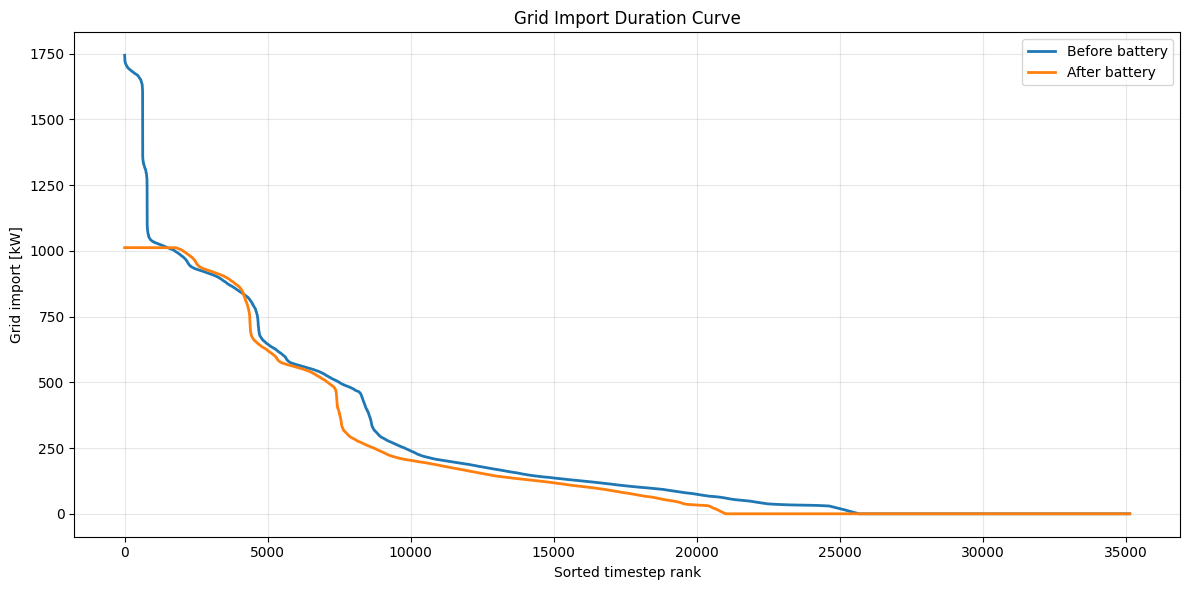

In [4]:
display(Markdown("## Grid Import Duration Curve"))

baseline_duration = df["baseline_grid_import"].sort_values(ascending=False).reset_index(drop=True)
optimized_duration = df["grid_flow"].sort_values(ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(baseline_duration.index + 1, baseline_duration, label="Before battery", linewidth=2)
ax.plot(optimized_duration.index + 1, optimized_duration, label="After battery", linewidth=2)
ax.set_xlabel("Sorted timestep rank")
ax.set_ylabel("Grid import [kW]")
ax.set_title("Grid Import Duration Curve")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
display(Markdown("## Monthly Savings and Peak Reduction"))
display(df_monthly.style.format({
    "monthly_import_cost_before": format_value,
    "monthly_import_cost_after": format_value,
    "monthly_savings": format_value,
    "monthly_peak_before": format_value,
    "monthly_peak_after": format_value,
    "monthly_peak_reduction": format_value,
}))

## Monthly Savings and Peak Reduction

,month,monthly_import_cost_before,monthly_import_cost_after,monthly_savings,monthly_peak_before,monthly_peak_after,monthly_peak_reduction
0,2024-01,"70,589.25","69,622.19",967.06,"1,704.81","1,012.58",692.23
1,2024-02,"60,567.41","54,816.79","5,750.62","1,710.51","1,012.58",697.93
2,2024-03,"58,841.98","49,102.32","9,739.66","1,699.59","1,012.58",687.01
3,2024-04,"47,959.72","35,527.78","12,431.94","1,105.51","1,012.58",92.94
4,2024-05,"47,867.65","35,379.19","12,488.46","1,081.39","1,012.58",68.82
5,2024-06,"42,686.35","30,298.93","12,387.42","1,033.82","1,012.58",21.25
6,2024-07,"47,271.79","32,415.52","14,856.27","1,048.24","1,012.58",35.66
7,2024-08,"46,918.89","32,722.56","14,196.33","1,042.85","1,012.58",30.27
8,2024-09,"46,896.26","37,965.68","8,930.58","1,062.53","1,012.58",49.95
9,2024-10,"64,052.08","58,730.72","5,321.36","1,719.56","1,012.58",706.99


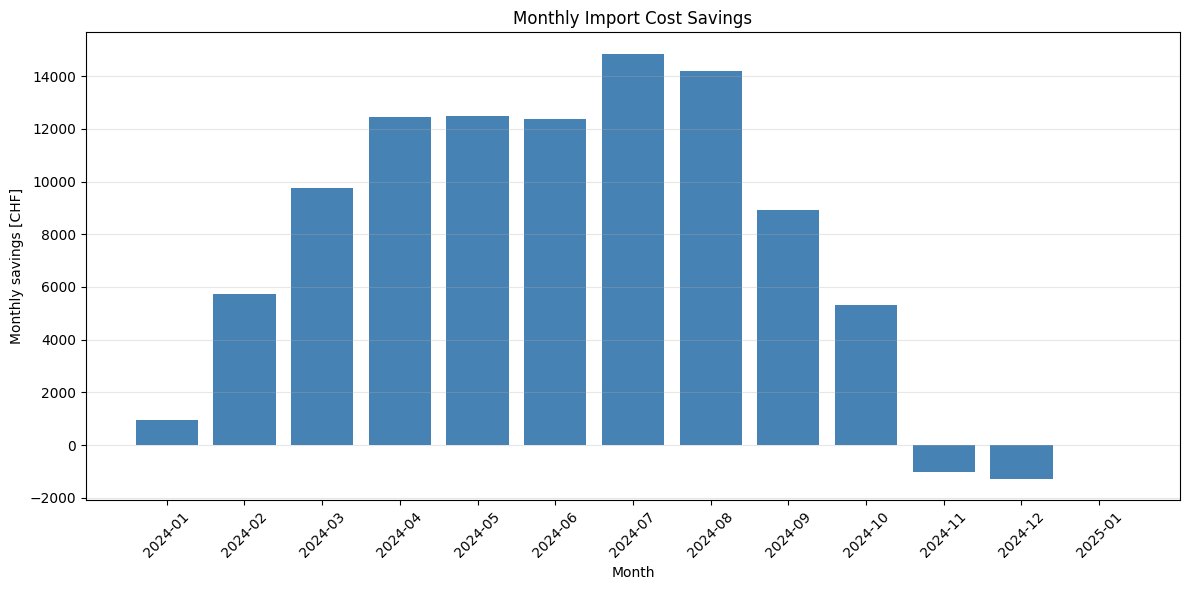

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_monthly["month"], df_monthly["monthly_savings"], color="steelblue")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly savings [CHF]")
ax.set_title("Monthly Import Cost Savings")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
display(Markdown("## Battery Utilization Metrics"))
display(df_battery_util.style.format({"Value": format_value}))

## Battery Utilization Metrics

,Metric,Value,Unit
0,Charged energy,"558,102.67",kWh/year
1,Discharged energy,"477,187.02",kWh/year
2,Equivalent full cycles,201.63,cycles/year
3,Average state of charge,970.51,kWh
4,Minimum state of charge,473.33,kWh
5,Maximum state of charge,"2,366.63",kWh
6,Hours near empty (<=10%),0.00,hours
7,Hours near full (>=90%),586.50,hours
8,Maximum charge power used,"1,000.00",kW
9,Maximum discharge power used,980.74,kW


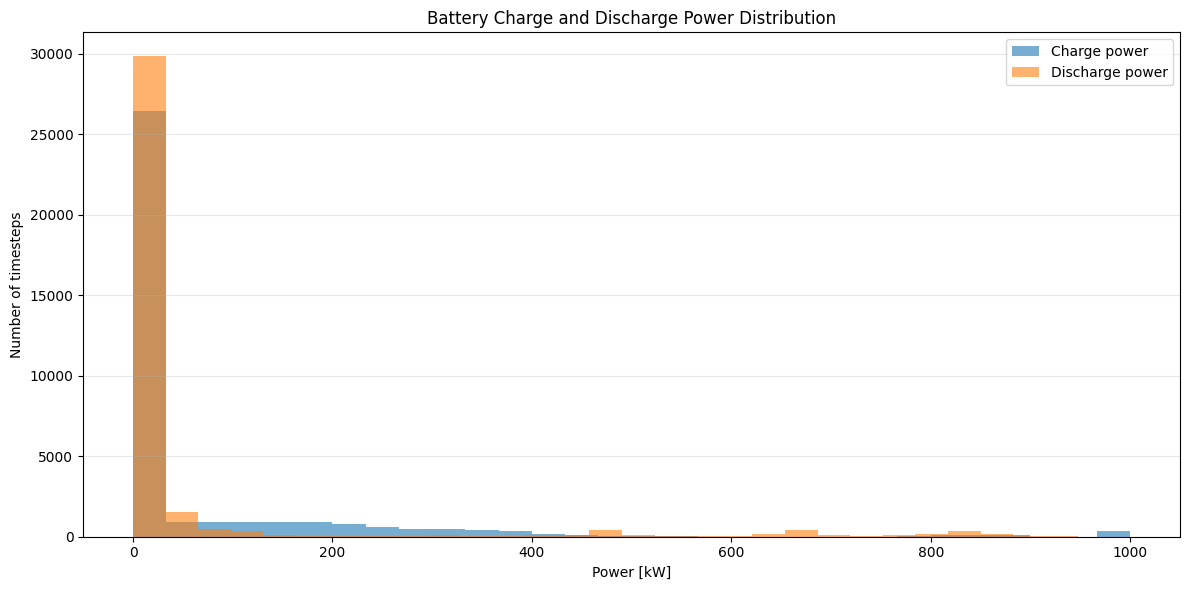

In [8]:
if {"battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(df["battery_charge_power"], bins=30, alpha=0.6, label="Charge power", color="tab:blue")
    ax.hist(df["battery_discharge_power"], bins=30, alpha=0.6, label="Discharge power", color="tab:orange")
    ax.set_xlabel("Power [kW]")
    ax.set_ylabel("Number of timesteps")
    ax.set_title("Battery Charge and Discharge Power Distribution")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_Run the model again to generate charge/discharge power distributions for this section._"))

In [9]:
display(Markdown("## Battery Size Sensitivity"))
if df_battery_sensitivity.empty:
    display(Markdown("_Run the model again to generate the battery size sensitivity analysis._"))
else:
    display(df_battery_sensitivity.style.format({
        "battery_size_kwh": format_value,
        "objective_total_cost": format_value,
        "import_cost": format_value,
        "peak_demand_cost": format_value,
        "annualized_battery_cost": format_value,
        "annual_savings": format_value,
        "npv": format_value,
        "irr": format_value,
        "payback_years": format_value,
        "discounted_payback_years": format_value,
    }))

## Battery Size Sensitivity

_Run the model again to generate the battery size sensitivity analysis._

In [10]:
plot_df = df_battery_sensitivity[df_battery_sensitivity["status"].isin(["baseline", "optimal"])].copy() if not df_battery_sensitivity.empty else df_battery_sensitivity
if not plot_df.empty:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(plot_df["battery_size_kwh"], plot_df["annual_savings"], marker="o", color="tab:blue")
    ax1.set_xlabel("Battery size [kWh]")
    ax1.set_ylabel("Annual savings [CHF/year]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(plot_df["battery_size_kwh"], plot_df["npv"], marker="s", color="tab:red")
    ax2.set_ylabel("NPV [CHF]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title("Sensitivity Plot of Battery Size vs NPV / Annual Savings")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_No sensitivity results available yet for this run._"))

_No sensitivity results available yet for this run._

## Representative Dispatch Weeks

,label,week_start
0,Winter Week,2024-12-09
1,Summer Week,2024-08-26
2,Highest-Curtailment Week,2024-05-06


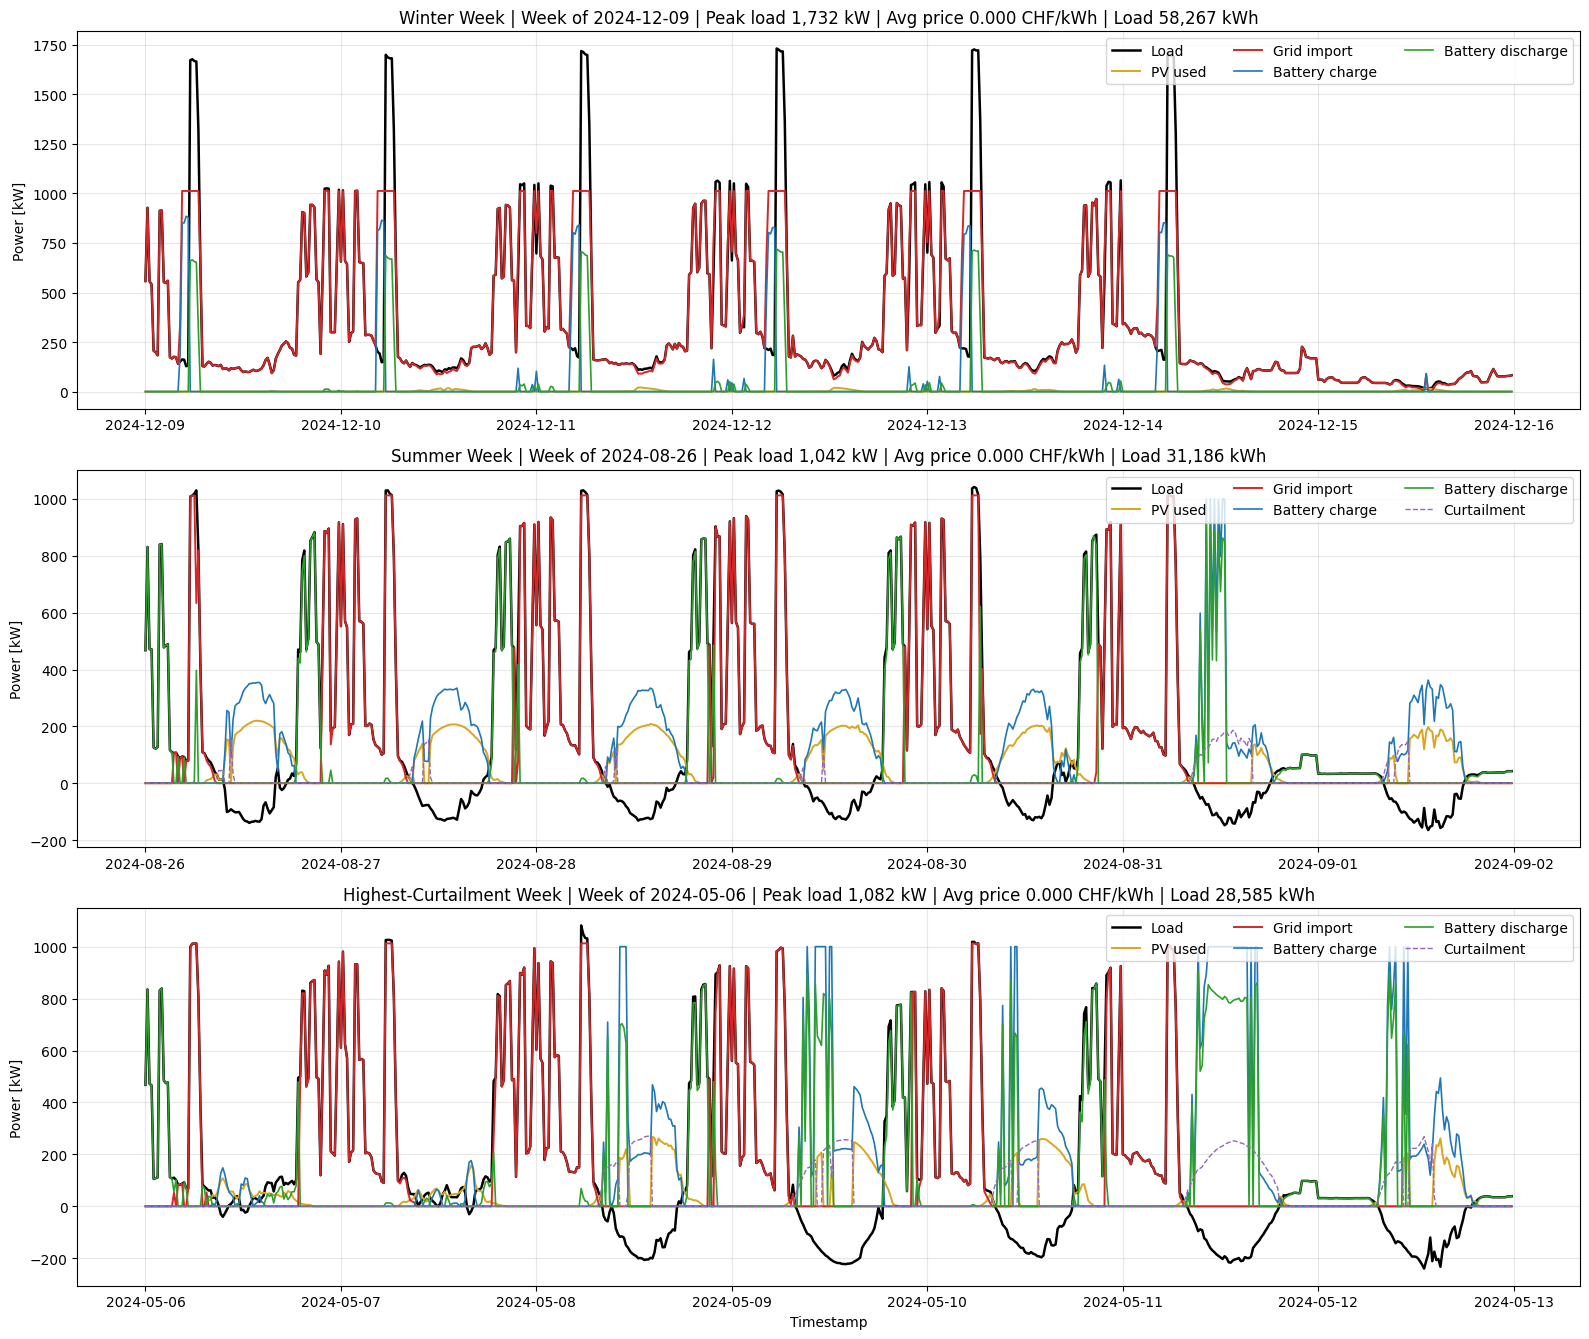

## Battery State of Charge (SOC) for Representative Weeks

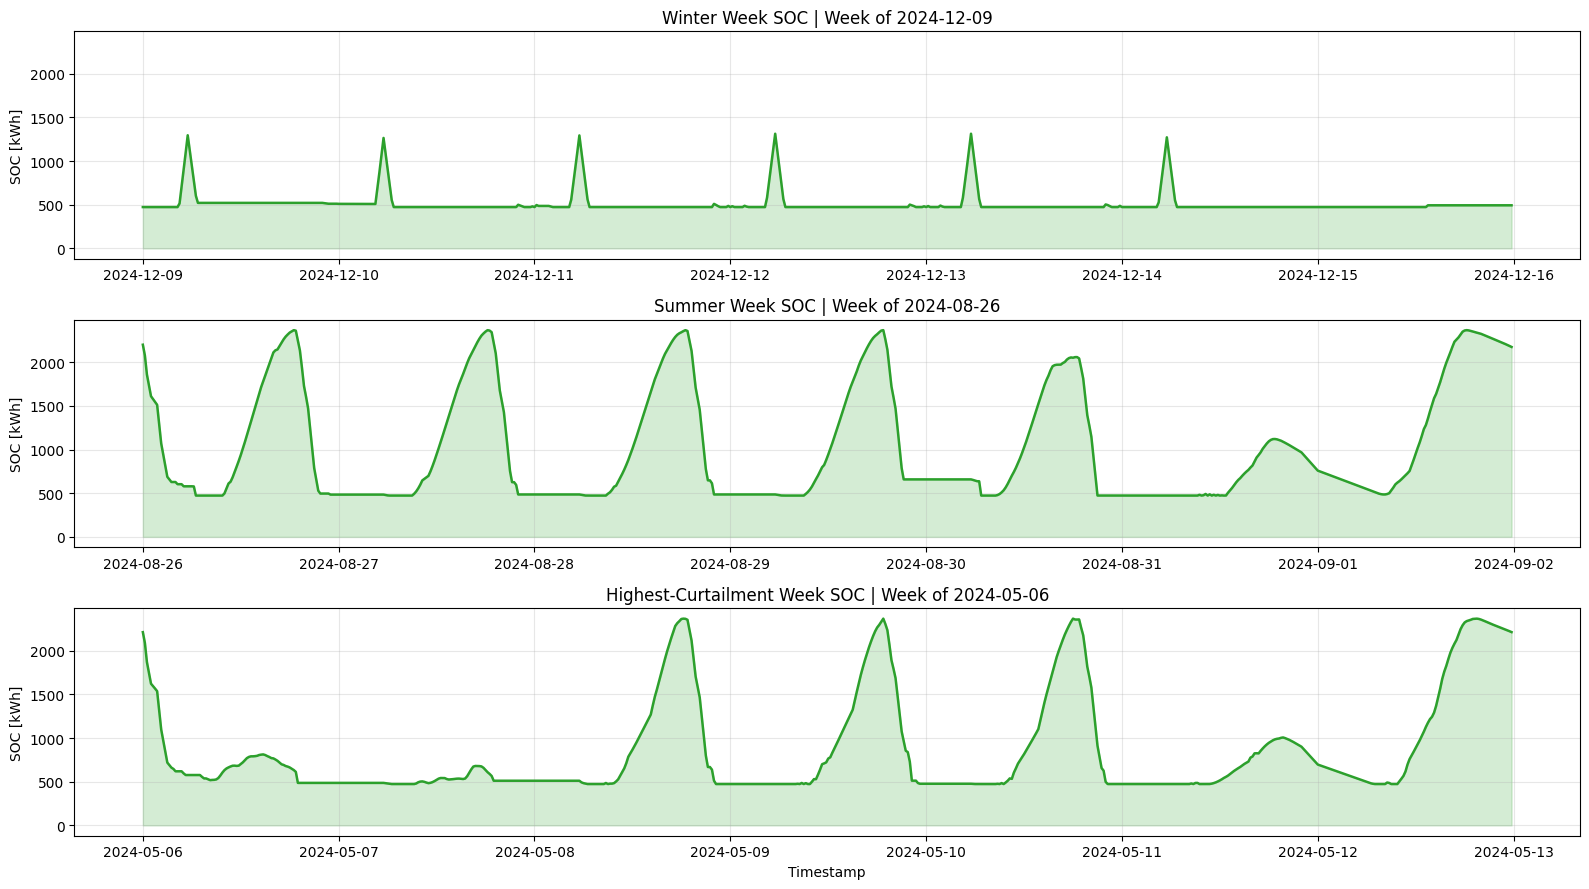

In [11]:
display(Markdown("## Representative Dispatch Weeks"))
if dispatch_week_table.empty:
    display(Markdown("_No representative dispatch weeks could be identified for this run._"))
else:
    display(dispatch_week_table.style.format({"week_start": lambda v: pd.to_datetime(v).strftime('%Y-%m-%d')}))
    n_weeks = len(dispatch_week_table)
    fig, axes = plt.subplots(n_weeks, 1, figsize=(16, 4.5 * n_weeks), sharex=False)
    if n_weeks == 1:
        axes = [axes]

    for ax, week_info in zip(axes, selected_dispatch_weeks):
        start = pd.to_datetime(week_info["week_start"])
        end = start + pd.Timedelta(days=7)
        week_df = dispatch_df[(dispatch_df["timestamp"] >= start) & (dispatch_df["timestamp"] < end)].copy()
        if week_df.empty:
            ax.text(0.5, 0.5, f"No data for {week_info['label']}", ha="center", va="center")
            ax.set_axis_off()
            continue

        ax.plot(week_df["timestamp"], week_df["total_load"], label="Load", color="black", linewidth=1.8)
        ax.plot(week_df["timestamp"], week_df["pv_flow"], label="PV used", color="goldenrod", linewidth=1.4)
        ax.plot(week_df["timestamp"], week_df["grid_flow"], label="Grid import", color="tab:red", linewidth=1.4)
        ax.plot(week_df["timestamp"], week_df["battery_charge_power"], label="Battery charge", color="tab:blue", linewidth=1.2)
        ax.plot(week_df["timestamp"], week_df["battery_discharge_power"], label="Battery discharge", color="tab:green", linewidth=1.2)
        if (week_df["spill_flow"] > 0).any():
            ax.plot(week_df["timestamp"], week_df["spill_flow"], label="Curtailment", color="tab:purple", linewidth=1.0, linestyle="--")

        total_load = week_df["total_load"].sum() * 0.25
        avg_price = week_df["electricity_price"].mean()
        peak_load = week_df["total_load"].max()
        ax.set_title(
            f"{week_info['label']} | Week of {start.strftime('%Y-%m-%d')} | "
            f"Peak load {peak_load:,.0f} kW | Avg price {avg_price:,.3f} CHF/kWh | Load {total_load:,.0f} kWh"
        )
        ax.set_ylabel("Power [kW]")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", ncol=3)

    plt.xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

display(Markdown("## Battery State of Charge (SOC) for Representative Weeks"))
if dispatch_week_table.empty:
    display(Markdown("_No representative dispatch weeks available for SOC plotting._"))
else:
    n_weeks = len(dispatch_week_table)
    fig, axes = plt.subplots(n_weeks, 1, figsize=(16, 3.0 * n_weeks), sharex=False, sharey=True)
    if n_weeks == 1:
        axes = [axes]
    for ax, week_info in zip(axes, selected_dispatch_weeks):
        start = pd.to_datetime(week_info["week_start"])
        end = start + pd.Timedelta(days=7)
        week_df = dispatch_df[(dispatch_df["timestamp"] >= start) & (dispatch_df["timestamp"] < end)].copy()
        if week_df.empty:
            ax.text(0.5, 0.5, f"No SOC data for {week_info['label']}", ha="center", va="center")
            ax.set_axis_off()
            continue
        ax.plot(week_df["timestamp"], week_df["battery_soc"], color="#2ca02c", lw=1.8)
        ax.fill_between(week_df["timestamp"], week_df["battery_soc"], alpha=0.2, color="#2ca02c")
        ax.set_title(f"{week_info['label']} SOC | Week of {start.strftime('%Y-%m-%d')}")
        ax.set_ylabel("SOC [kWh]")
        ax.grid(True, alpha=0.3)
    plt.xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

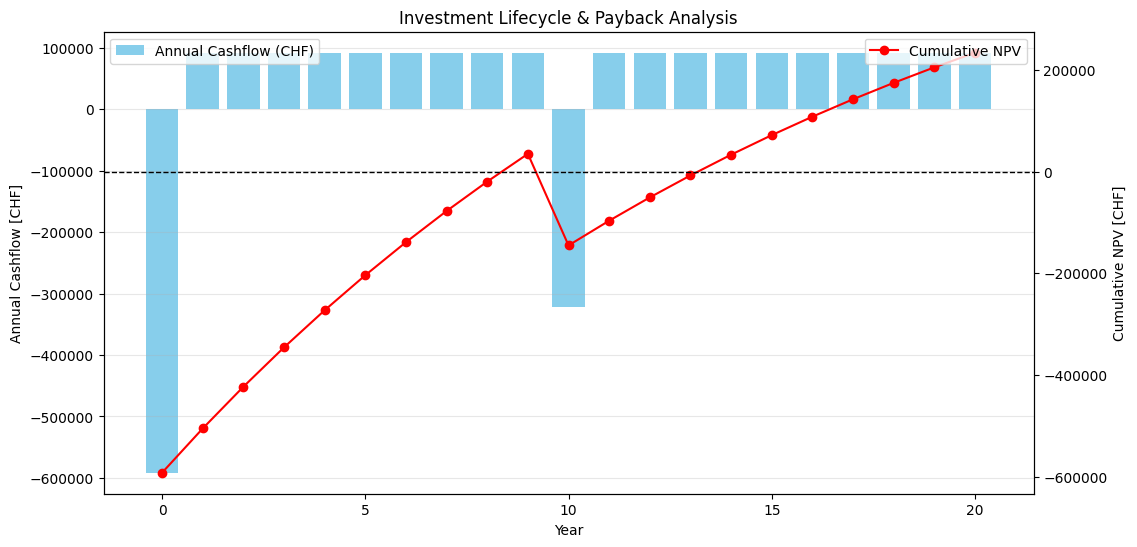

**Payback Period:** 7 years

**Discounted Payback Period:** 9 years

**Net Present Value (NPV):** CHF 233,374.39

**Internal Rate of Return (IRR):** 0.1088

**Battery Replacement:** CHF 414,159.58 in year 10

**Curtailed Energy:** 73,343.11 kWh/year

## Detailed Output Summary

,Metric,Value
0,battery_capacity_kwh,"2,366.63"
1,objective_total_cost,"655,134.49"
2,opex,"593,425.42"
3,import_cost,"583,425.42"
4,fixed_om_cost,"10,000.00"
5,annualized_battery_cost,"51,583.31"
6,peak_demand_cost,"10,125.76"
7,yearly_peak,"1,012.58"
8,monthly_peaks,{}
9,sum_monthly_peaks,0.00


In [12]:
## 3. Financial Projection
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_fin['year'], df_fin['cashflow'], color='skyblue', label='Annual Cashflow (CHF)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Cashflow [CHF]')

ax2 = ax1.twinx()
ax2.plot(df_fin['year'], df_fin['discounted_cashflow'].cumsum(), color='red', marker='o', label='Cumulative NPV')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_ylabel('Cumulative NPV [CHF]')

plt.title("Investment Lifecycle & Payback Analysis")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
plt.show()

display(Markdown(f"**Payback Period:** {summary.get('payback_years', 'N/A')} years"))
display(Markdown(f"**Discounted Payback Period:** {summary.get('discounted_payback_years', 'N/A')} years"))
display(Markdown(f"**Net Present Value (NPV):** CHF {summary.get('npv', 0):,.2f}"))
display(Markdown(f"**Internal Rate of Return (IRR):** {summary.get('irr', float('nan')):,.4f}"))
display(Markdown(f"**Battery Replacement:** CHF {summary.get('replacement_cost', 0):,.2f} in year {summary.get('replacement_year', 'N/A')}"))
display(Markdown(f"**Curtailed Energy:** {summary.get('curtailed_energy_kwh', 0):,.2f} kWh/year"))

display(Markdown("## Detailed Output Summary"))
display(detailed_summary_df.style.format({"Value": format_value}))